# P5: A Latent World Model of My Tennis Swings

This notebook teaches world models by building one on real video: 11 handheld
phone clips of my forehands and backhands. We predict the *next frame* not in
pixels but in a **latent space**.

We follow the real research arc, including a failure and the fix:
1. what a world model is, 2. encode frames with a frozen network, 3. a naive model
that *loses to doing nothing*, 4. diagnose why, 5. fix it so it beats the baseline,
6. test whether swing-type conditioning works (it does not, and we learn why),
7. visualize a "dream". Connects to P1 (latent control) and P2 (action dreaming).

## 1. What is a world model?

A world model learns **dynamics**: given the current state (and optionally an
action), predict the next state, `s_t -> s_{t+1}`. Roll it forward and it can
*imagine* the future without the real world.

Here the **state** is a latent embedding of a video frame and the **dynamics** is
a small recurrent network we train. The swing type (forehand/backhand) is a
candidate **action/intent** we will try to condition on.

Why latent and not pixels? With only ~490 frames a pixel model cannot learn what
the world looks like, so it predicts blur. A frozen pretrained encoder gives good
visual features for free, so the model only learns the part that is learnable:
how the latent moves.

In [1]:
from pathlib import Path
import numpy as np, torch, matplotlib.pyplot as plt
from vlawm.tennis.data import discover_clips, decode_clip, LABEL_NAMES
from vlawm.tennis.encoder import load_encoder, embed_clip_cached
from vlawm.tennis.prep import clean_mask, Standardizer
from vlawm.tennis.evaluate import persistence_rollout, rollout_error
from vlawm.tennis.retrieval import ReferenceBank
from vlawm.worldmodel.tennis_wm import SwingConditionedDynamics

ROOT = Path.cwd() if Path.cwd().name=='p5_tennis_world_model' else Path.cwd()/'p5_tennis_world_model'
RAW, EMB = ROOT/'data'/'raw', ROOT/'data'/'embeddings'
DEVICE = torch.device('cpu')
CONTEXT, HORIZON, EPOCHS, WD = 4, 10, 150, 1e-3

## 2. Load and peek at the data\nDecode the clips and look at a forehand vs a backhand frame.

11 clips


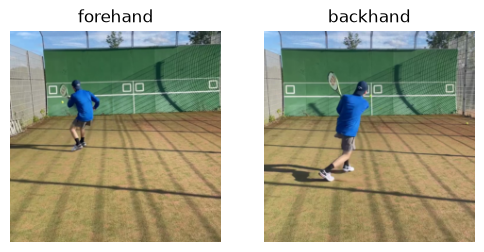

In [2]:
clips = discover_clips(RAW)
print(len(clips), 'clips')
frames = {c.name: decode_clip(c) for c in clips}
fh = next(c for c in clips if c.label==0); bh = next(c for c in clips if c.label==1)
fig, ax = plt.subplots(1,2, figsize=(6,3))
ax[0].imshow(frames[fh.name][len(frames[fh.name])//2]); ax[0].set_title('forehand'); ax[0].axis('off')
ax[1].imshow(frames[bh.name][len(frames[bh.name])//2]); ax[1].set_title('backhand'); ax[1].axis('off')
plt.show()

## 3. Encode frames with frozen DINOv2

DINOv2 is a vision transformer Meta trained self-supervised on 142M images. We
freeze it and use it as a fixed function: frame -> 384-number vector (the CLS
token, a global summary). Each clip becomes a trajectory through latent space.

Then we project all latents to 2D with PCA, colored by swing type. **Watch
whether forehand and backhand separate.**

Using cache found in /Users/silv/.cache/torch/hub/facebookresearch_dinov2_main
/Users/silv/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/silv/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/silv/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


latent shape per clip e.g.: (46, 384)


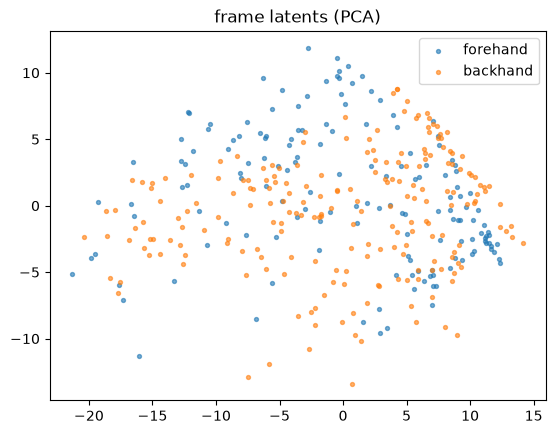

In [3]:
encoder = load_encoder(DEVICE)
emb = {}
for c in clips:
    raw = embed_clip_cached(encoder, frames[c.name], EMB, c.name)
    keep = clean_mask(raw)              # drop corrupt motion-blur frames (see sec 4/5)
    emb[c.name] = raw[keep]; frames[c.name] = frames[c.name][keep]
print('latent shape per clip e.g.:', emb[clips[0].name].shape)

from sklearn.decomposition import PCA
X = np.concatenate([emb[c.name] for c in clips])
y = np.concatenate([[c.label]*emb[c.name].shape[0] for c in clips])
P = PCA(2).fit_transform(X)
for l in (0,1): plt.scatter(P[y==l,0], P[y==l,1], s=8, alpha=.6, label=LABEL_NAMES[l])
plt.legend(); plt.title('frame latents (PCA)'); plt.show()

**Observation:** the two classes overlap heavily. The CLS token is dominated by
the shared scene (same court, same person); the small moving arm that distinguishes
the swings is mostly suppressed. Keep this in mind for section 6.

## 4. A first (naive) model, and an honest failure

Let's build the dynamics model and train it the obvious way: on the **raw** latents,
no standardization. We compare against **persistence** = "predict no change", the
baseline any real dynamics model must beat.

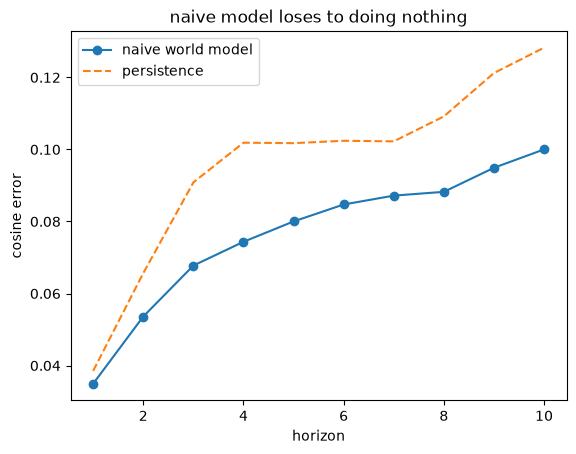

In [4]:
def build_windows(emb_d, lab_d):
    ctx,tgt,lab=[],[],[]
    for n,e in emb_d.items():
        if e.shape[0] < CONTEXT+HORIZON: continue
        for s in range(e.shape[0]-CONTEXT-HORIZON+1):
            ctx.append(e[s:s+CONTEXT]); tgt.append(e[s+CONTEXT:s+CONTEXT+HORIZON]); lab.append(lab_d[n])
    return np.stack(ctx).astype('float32'), np.stack(tgt).astype('float32'), np.array(lab)

def train(emb_d, lab_d, conditioned, standardizer=None):
    e = emb_d if standardizer is None else {n:standardizer.transform(v) for n,v in emb_d.items()}
    ctx,tgt,lab = build_windows(e, lab_d)
    torch.manual_seed(0)
    m = SwingConditionedDynamics(conditioned=conditioned)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=WD)
    C,T,L = torch.from_numpy(ctx),torch.from_numpy(tgt),torch.from_numpy(lab)
    for _ in range(EPOCHS):
        opt.zero_grad(); torch.nn.functional.mse_loss(m.rollout(C,L,HORIZON),T).backward(); opt.step()
    return m

lab = {c.name:c.label for c in clips}
hold = clips[0].name
tr = {n:emb[n] for n in emb if n!=hold}; te={hold:emb[hold]}
m_naive = train(tr, lab, conditioned=False)          # RAW latents, no standardization
tc,tt,tl = build_windows(te, lab)
pred = m_naive.rollout(torch.from_numpy(tc), torch.from_numpy(tl), HORIZON).detach().numpy()
pp = persistence_rollout(tc, HORIZON)
h=np.arange(1,HORIZON+1)
plt.plot(h, rollout_error(pred,tt),'-o',label='naive world model')
plt.plot(h, rollout_error(pp,tt),'--',label='persistence')
plt.legend(); plt.xlabel('horizon'); plt.ylabel('cosine error'); plt.title('naive model loses to doing nothing'); plt.show()

**The naive model loses to persistence.** That is a real result, not a bug in
the code. Time to diagnose instead of guessing.

## 5. Diagnose: why does it lose?

Two measurements explain it.

In [5]:
# (a) How fast do the latents actually move?
def cosd(a,b):
    a=a/np.linalg.norm(a,axis=-1,keepdims=True); b=b/np.linalg.norm(b,axis=-1,keepdims=True)
    return 1-(a*b).sum(-1)
step = np.concatenate([cosd(emb[c.name][:-1], emb[c.name][1:]) for c in clips])
print('consecutive-frame cosine distance: %.4f (tiny -> persistence is strong)'%step.mean())

# (b) Do the latent dimensions have wildly different scales? (breaks raw MSE)
sd = np.concatenate([emb[c.name] for c in clips]).std(0)
print('per-dim std: min=%.3f max=%.3f ratio=%.1fx'%(sd.min(), sd.max(), sd.max()/sd.min()))

consecutive-frame cosine distance: 0.0260 (tiny -> persistence is strong)
per-dim std: min=0.361 max=1.354 ratio=3.7x


**Findings:** (a) dynamics are slow, so persistence is a strong baseline and the
model must extrapolate *velocity* to beat it. (b) the latent dims have very
different scales, so raw MSE is dominated by a few dims and the model cannot learn
the rest. **Fix:** standardize the latents (per-dim z-score) before modeling, and
we already dropped corrupt frames in section 3.

## 6. Can we condition on swing type? (test before trusting)

Before building a forehand-vs-backhand conditioned model, check if swing type is
even decodable from the latent on **held-out** clips. We train a linear probe on
all-but-one clip and test on the held-out one, averaged over all clips
(leave-one-out).

In [6]:
from sklearn.linear_model import LogisticRegression
tr_acc, te_acc = [], []
names=[c.name for c in clips]
for hld in names:
    Xtr=np.concatenate([emb[n] for n in names if n!=hld]); ytr=np.concatenate([[lab[n]]*emb[n].shape[0] for n in names if n!=hld])
    clf=LogisticRegression(max_iter=2000).fit(Xtr,ytr)
    tr_acc.append(clf.score(Xtr,ytr)); te_acc.append(clf.score(emb[hld],[lab[hld]]*emb[hld].shape[0]))
print('linear probe: train=%.2f  held-out=%.2f  (chance 0.5)'%(np.mean(tr_acc), np.mean(te_acc)))

linear probe: train=1.00  held-out=0.62  (chance 0.5)


Train accuracy is ~1.0 but held-out is only ~0.6: the model memorizes training
clips, and swing type barely generalizes. **Prediction:** conditioning the dynamics
on this label will not help and may hurt. Let's verify in section 7.

## 7. The fixed model: standardize, then leave-one-out evaluate

We retrain unconditioned and conditioned models on standardized, cleaned latents,
and evaluate with leave-one-clip-out cross-validation (robust, unlike a single
2-clip test split).

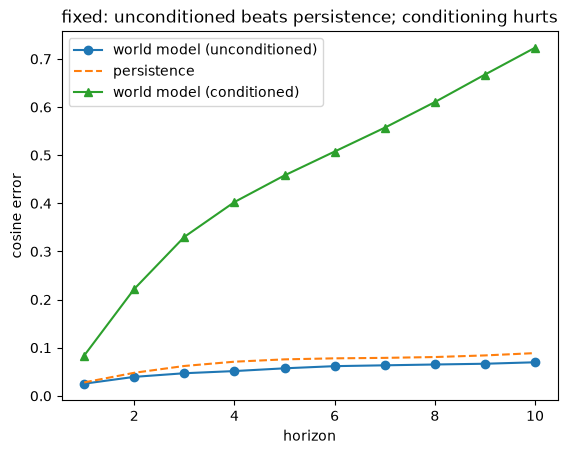

h=10  uncond=0.070  persist=0.089  cond=0.723


In [7]:
e_un,e_co,e_pe=[],[],[]
for hld in names:
    tr={n:emb[n] for n in names if n!=hld}; te={hld:emb[hld]}
    std=Standardizer.fit(np.concatenate(list(tr.values())))
    mu=train(tr,lab,False,std); mc=train(tr,lab,True,std)
    tc,tt,tl=build_windows({hld:std.transform(emb[hld])}, lab)
    with torch.no_grad():
        pu=mu.rollout(torch.from_numpy(tc),torch.from_numpy(tl),HORIZON).numpy()
        pc=mc.rollout(torch.from_numpy(tc),torch.from_numpy(tl),HORIZON).numpy()
    pp=persistence_rollout(tc,HORIZON)
    e_un.append(rollout_error(std.inverse(pu),std.inverse(tt)))
    e_co.append(rollout_error(std.inverse(pc),std.inverse(tt)))
    e_pe.append(rollout_error(std.inverse(pp),std.inverse(tt)))
e_un,e_co,e_pe=np.mean(e_un,0),np.mean(e_co,0),np.mean(e_pe,0)
plt.plot(h,e_un,'-o',label='world model (unconditioned)')
plt.plot(h,e_pe,'--',label='persistence')
plt.plot(h,e_co,'-^',label='world model (conditioned)')
plt.legend(); plt.xlabel('horizon'); plt.ylabel('cosine error'); plt.title('fixed: unconditioned beats persistence; conditioning hurts'); plt.show()
print('h=10  uncond=%.3f  persist=%.3f  cond=%.3f'%(e_un[-1],e_pe[-1],e_co[-1]))

**Result:** the unconditioned world model now beats persistence at every horizon
(it learned to extrapolate the swing trajectory). The conditioned model is much
worse: given the label it predicts the *average* training swing of that class and
overrides the actual context. This matches the weak probe in section 6: the swing
label is not reliable signal here, so conditioning on it injects noise.

This is the honest headline of P5: **a frozen-latent world model that beats
persistence on real video**, plus a clean diagnosis of why intent-conditioning
needs more data / a motion-aware representation.

## 8. Watch a "dream" via nearest-neighbor retrieval

A latent rollout is not directly watchable. We map each predicted latent to the
real frame whose latent is closest (cosine) and stitch them into a predicted
continuation of the swing.

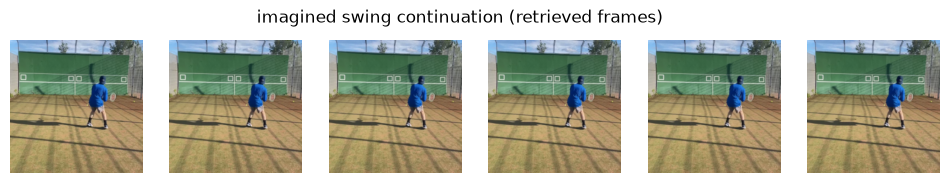

In [8]:
demo=names[0]
std=Standardizer.fit(np.concatenate([emb[n] for n in names if n!=demo]))
mu=train({n:emb[n] for n in names if n!=demo}, lab, False, std)
ctx0=torch.from_numpy(std.transform(emb[demo])[None,:CONTEXT]).float()
with torch.no_grad():
    roll=std.inverse(mu.rollout(ctx0, torch.tensor([lab[demo]]), HORIZON).numpy()[0])
bank=ReferenceBank(np.concatenate([emb[n] for n in names]), np.concatenate([frames[n] for n in names]))
dream=bank.retrieve_frames(roll)
fig,ax=plt.subplots(1,min(6,HORIZON),figsize=(2*min(6,HORIZON),2))
for i in range(min(6,HORIZON)): ax[i].imshow(dream[i]); ax[i].axis('off')
plt.suptitle('imagined swing continuation (retrieved frames)'); plt.show()

## 9. Reflection and thesis directions

**What worked:** dynamics in a frozen latent space are learnable from tiny data
once standardized; the world model beats persistence by extrapolating velocity.

**What did not, and why:** swing-type conditioning. The DINOv2 CLS token is a
recognition feature that is invariant to the very motion that defines a swing, and
11 clips is too few for the label to generalize.

**Try changing X:** set `CONTEXT` to 2 or 6; remove standardization to reproduce
the failure; try DINOv2 patch tokens instead of the CLS token to expose arm/racket
position.

**Thesis directions:** scale data; use a motion-aware state (patch tokens, frame
stacks, or pose); decode latents to pixels; and place this world model inside a VLA
control loop on real video, extending P1 from simulation to the real world.